In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import h5py
import scipy.sparse as sp
import yaml
import time
import gget
import scipy
from scipy.stats import zscore
from tqdm import tqdm
from statsmodels.stats.multitest import multipletests
from scipy.spatial.distance import cdist

import anndata as an
import scanpy as sc
import scanpy.external as sce
import rapids_singlecell as rsc
import scvi


import cupy as cp
from cuml.manifold import TSNE
from cuml.decomposition import PCA

sc.settings.verbosity = 3

16:51:09 - INFO - Old pandas version detected. Patching DataFrame.map to DataFrame.applymap
/nfs/turbo/umms-indikar/Cooper/conda_envs/scrapids/lib/python3.12/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_categorical_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)
/nfs/turbo/umms-indikar/Cooper/conda_envs/scrapids/lib/python3.12/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_continuous_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)


In [2]:
%%time
fpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/cc_fibroblast_full/anndata/cell_cycle_annotated.h5ad"
adata = sc.read_h5ad(fpath)
adata

CPU times: user 198 ms, sys: 900 ms, total: 1.1 s
Wall time: 2.75 s


AnnData object with n_obs × n_vars = 7541 × 21412
    obs: 'phase', 'barcoded_phase', 'S_score', 'G2M_score'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'g2m_genes', 's_genes'
    layers: 'log_norm', 'raw_counts'

[2025-05-08 16:51:26.344] [CUML] [debug] n_neighbors=500
[2025-05-08 16:51:26.344] [CUML] [debug] Calling knn graph run
[2025-05-08 16:51:26.344] [CUML] [debug] Done. Calling fuzzy simplicial set
[2025-05-08 16:51:26.409] [CUML] [debug] Done. Calling remove zeros
running PAGA
    finished: added
    'paga/connectivities', connectivities adjacency (adata.uns)
    'paga/connectivities_tree', connectivities subtree (adata.uns) (0:00:04)
--> added 'pos', the PAGA positions (adata.uns['paga'])


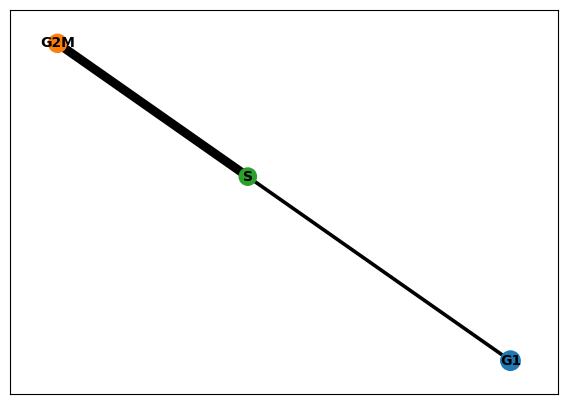

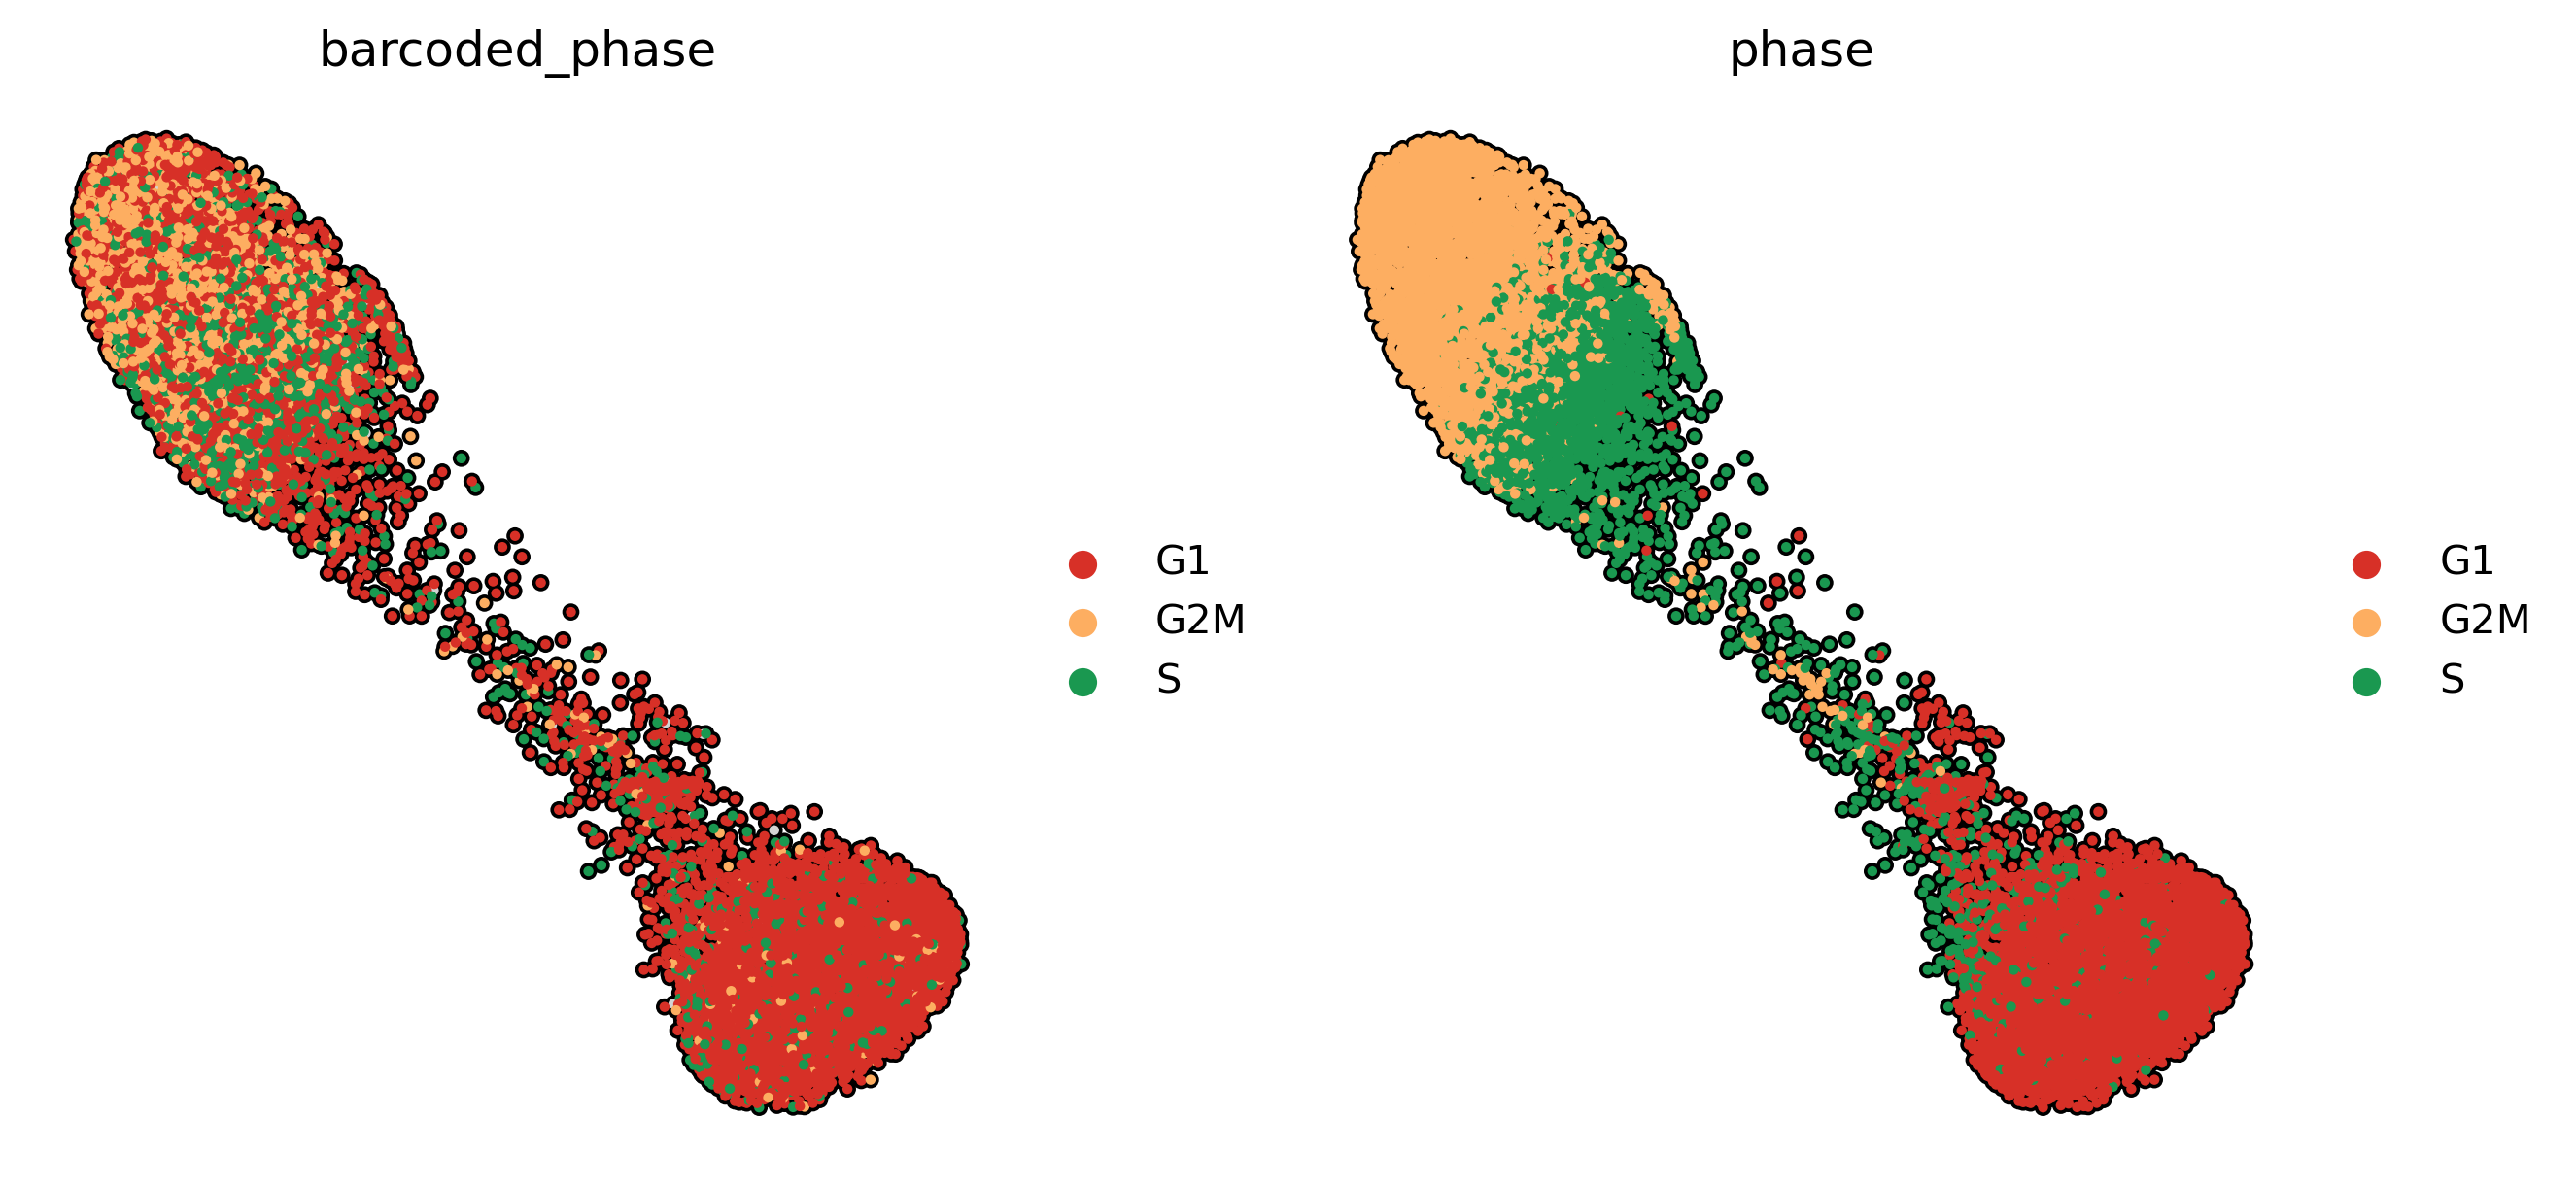

In [3]:
rsc.pp.pca(adata)
rsc.pp.neighbors(adata, n_neighbors=500)
sc.tl.paga(adata, groups='phase')
sc.pl.paga(adata)
rsc.tl.draw_graph(adata, init_pos='paga')

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 4.25, 4.75

palette = {
    "G1": "#D73027",        # strong red (Cdt1+)
    "S": "#1A9850",         # green (Geminin+)
    "G2M": "#FDAE61",       # orange-yellow (Cdt1+/Geminin+)
    "unknown": "#B0B0B0", # Neutral gray
}

sc.pl.draw_graph(
    adata, 
    color=['barcoded_phase', 'phase'],
    size=25,
    ncols=3,
    alpha=1,
    use_raw=False,
    add_outline=True,
    na_in_legend=False,
    outline_color=('k', 'k'),
    frameon=False,
    palette=palette
)

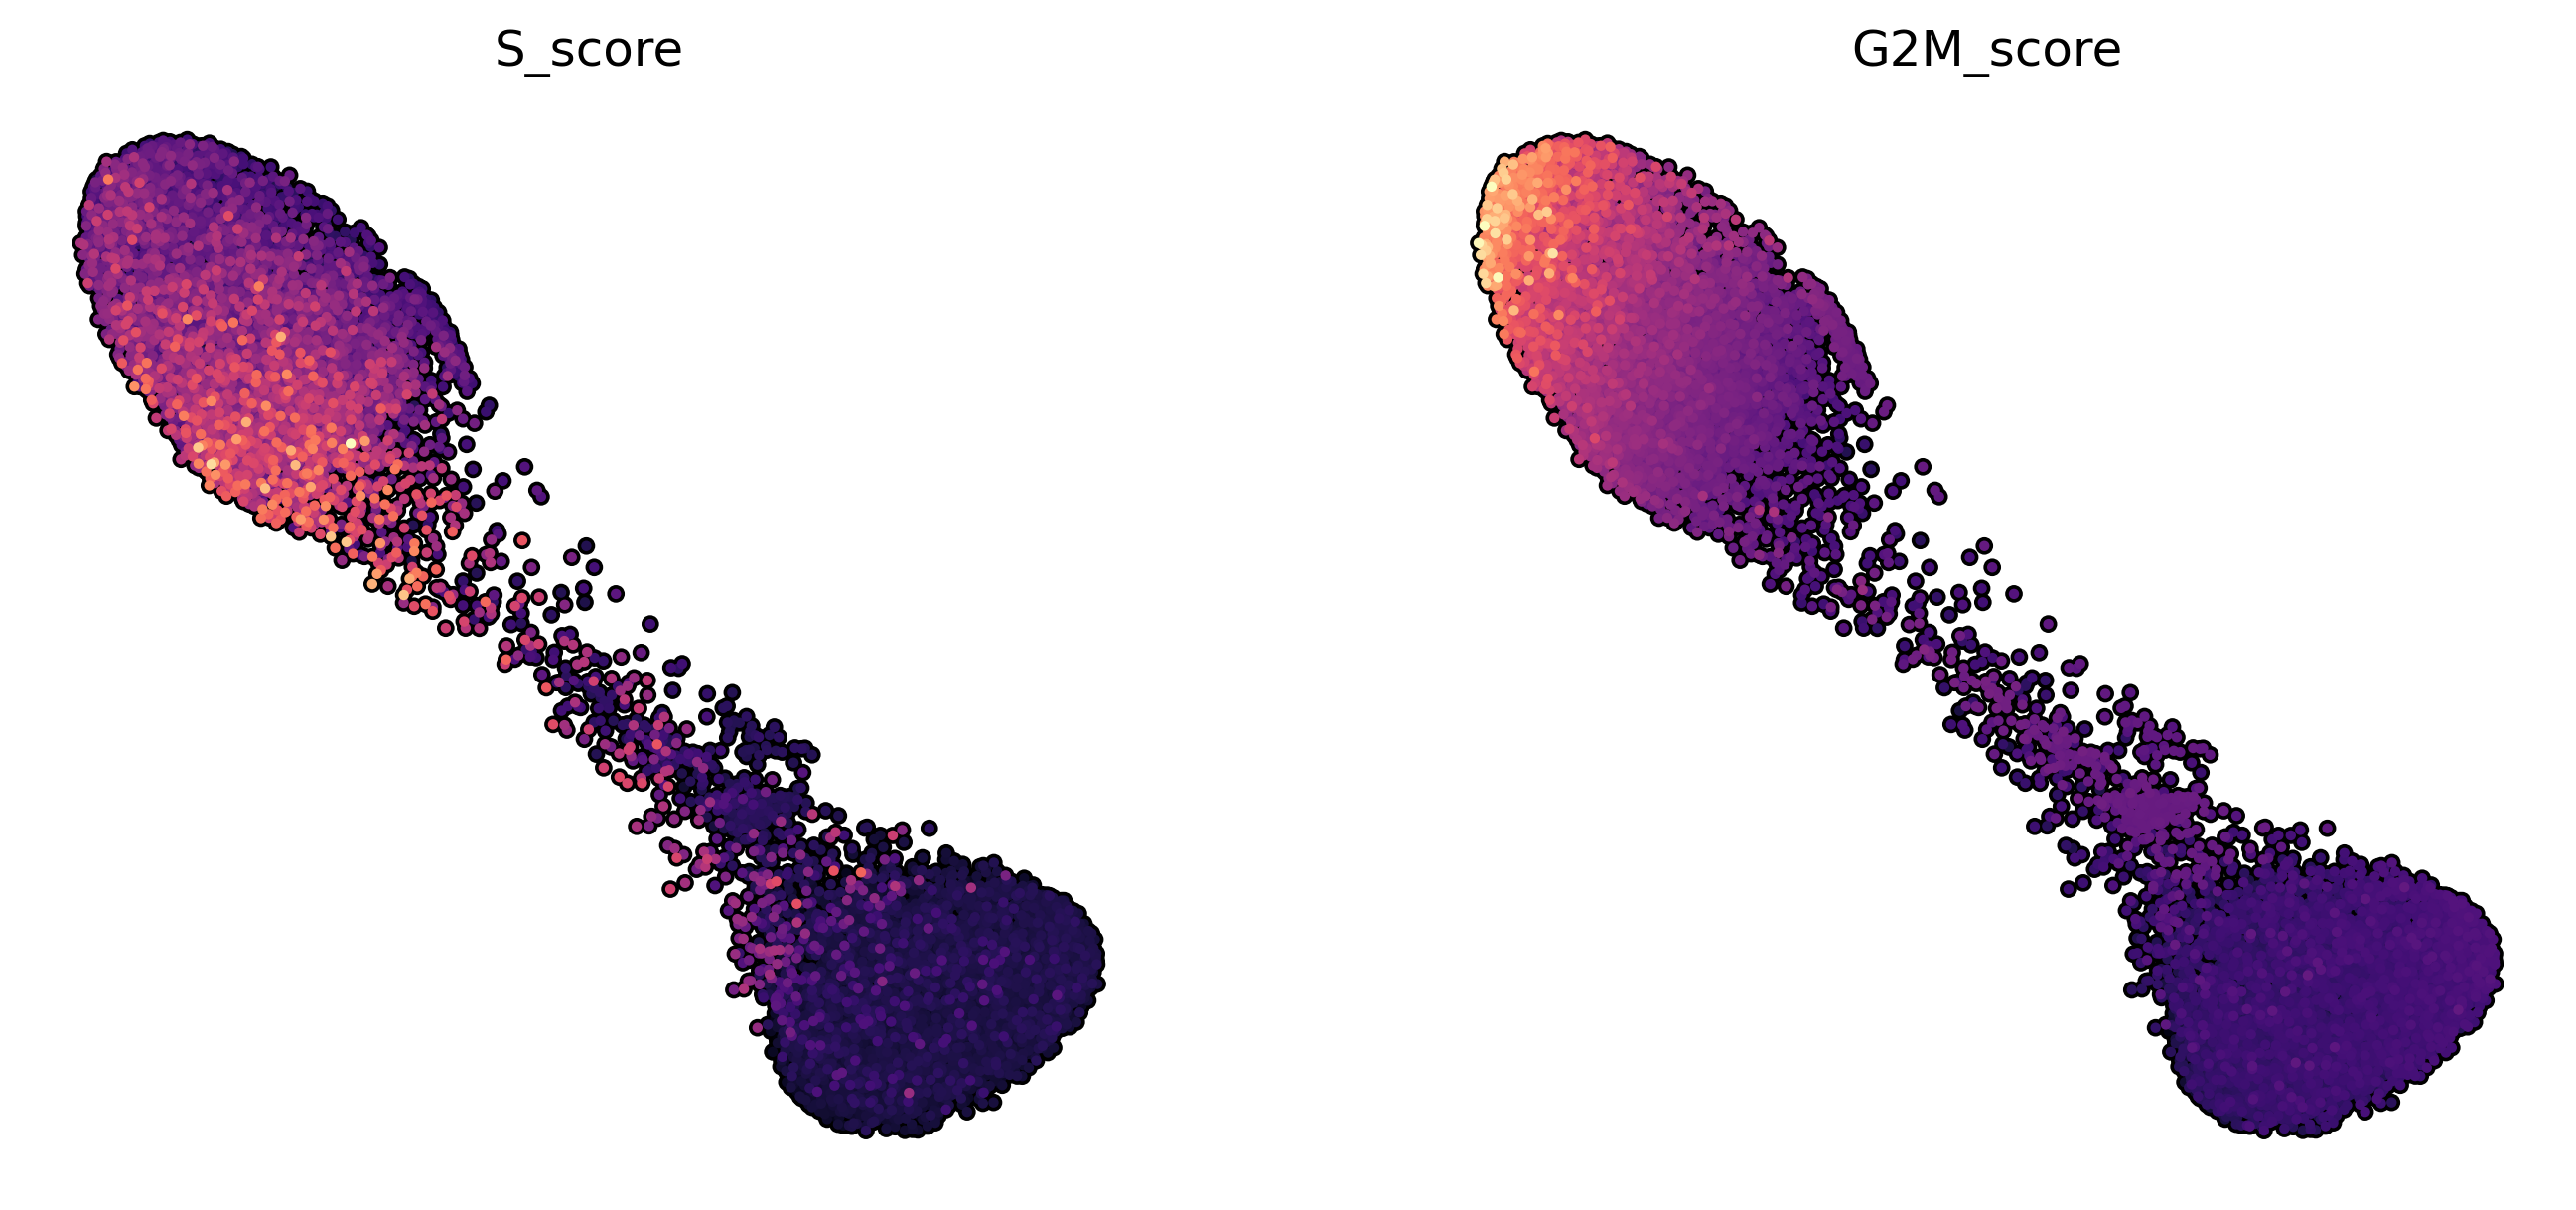

In [4]:
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 4.25, 4.75

sc.pl.draw_graph(
    adata, 
    color=['S_score', 'G2M_score',],
    size=25,
    ncols=3,
    alpha=1,
    use_raw=False,
    add_outline=True,
    na_in_legend=False,
    colorbar_loc=None,
    cmap='magma',
    outline_color=('k', 'k'),
    frameon=False,
    wspace=0.25,
)

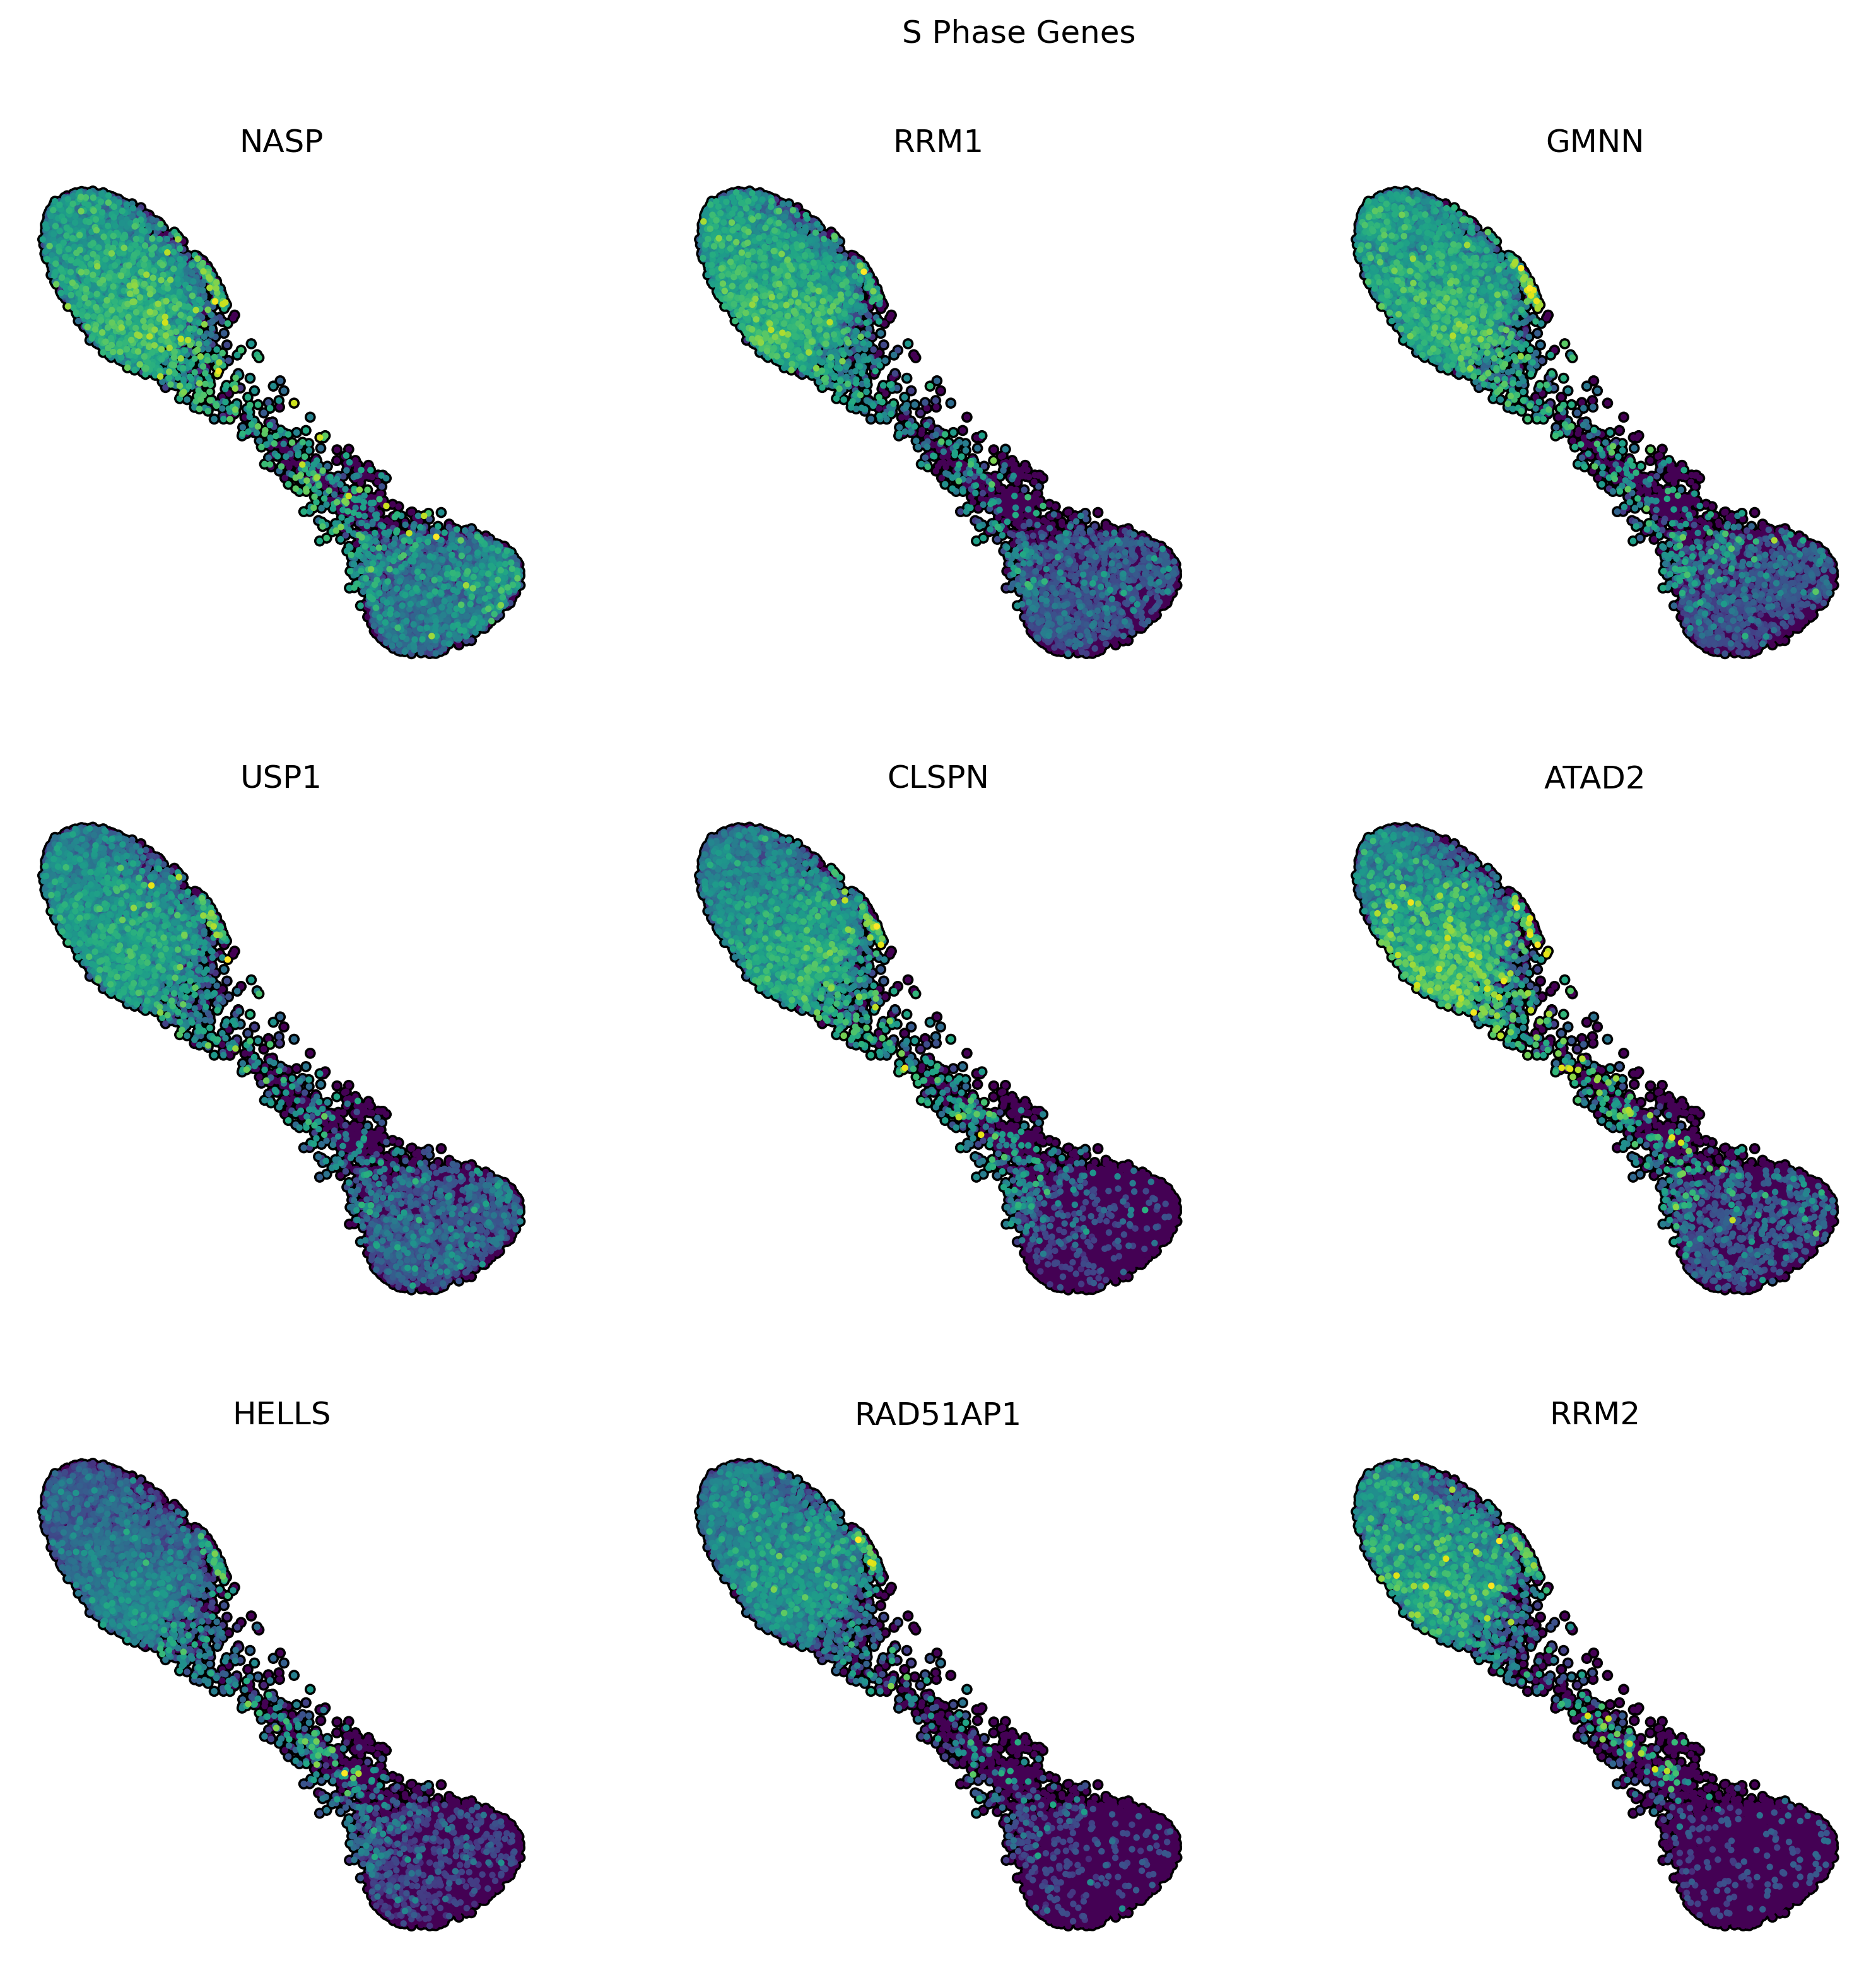

In [5]:
# get higest expressed S phase genes
s_genes = adata.uns['s_genes']
mean_expr = adata[:, s_genes].X.mean(axis=0).A1  
top9_genes = [s_genes[i] for i in mean_expr.argsort()[::-1][:9]]

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 3.25, 3.75

fig = sc.pl.draw_graph(
    adata, 
    color=top9_genes,
    size=25,
    ncols=3,
    alpha=1,
    use_raw=False,
    add_outline=True,
    na_in_legend=False,
    colorbar_loc=None,
    outline_color=('k', 'k'),
    frameon=False,
    show=False, 
    return_fig=True,  
)

fig.suptitle("S Phase Genes", y=0.95)
plt.show()

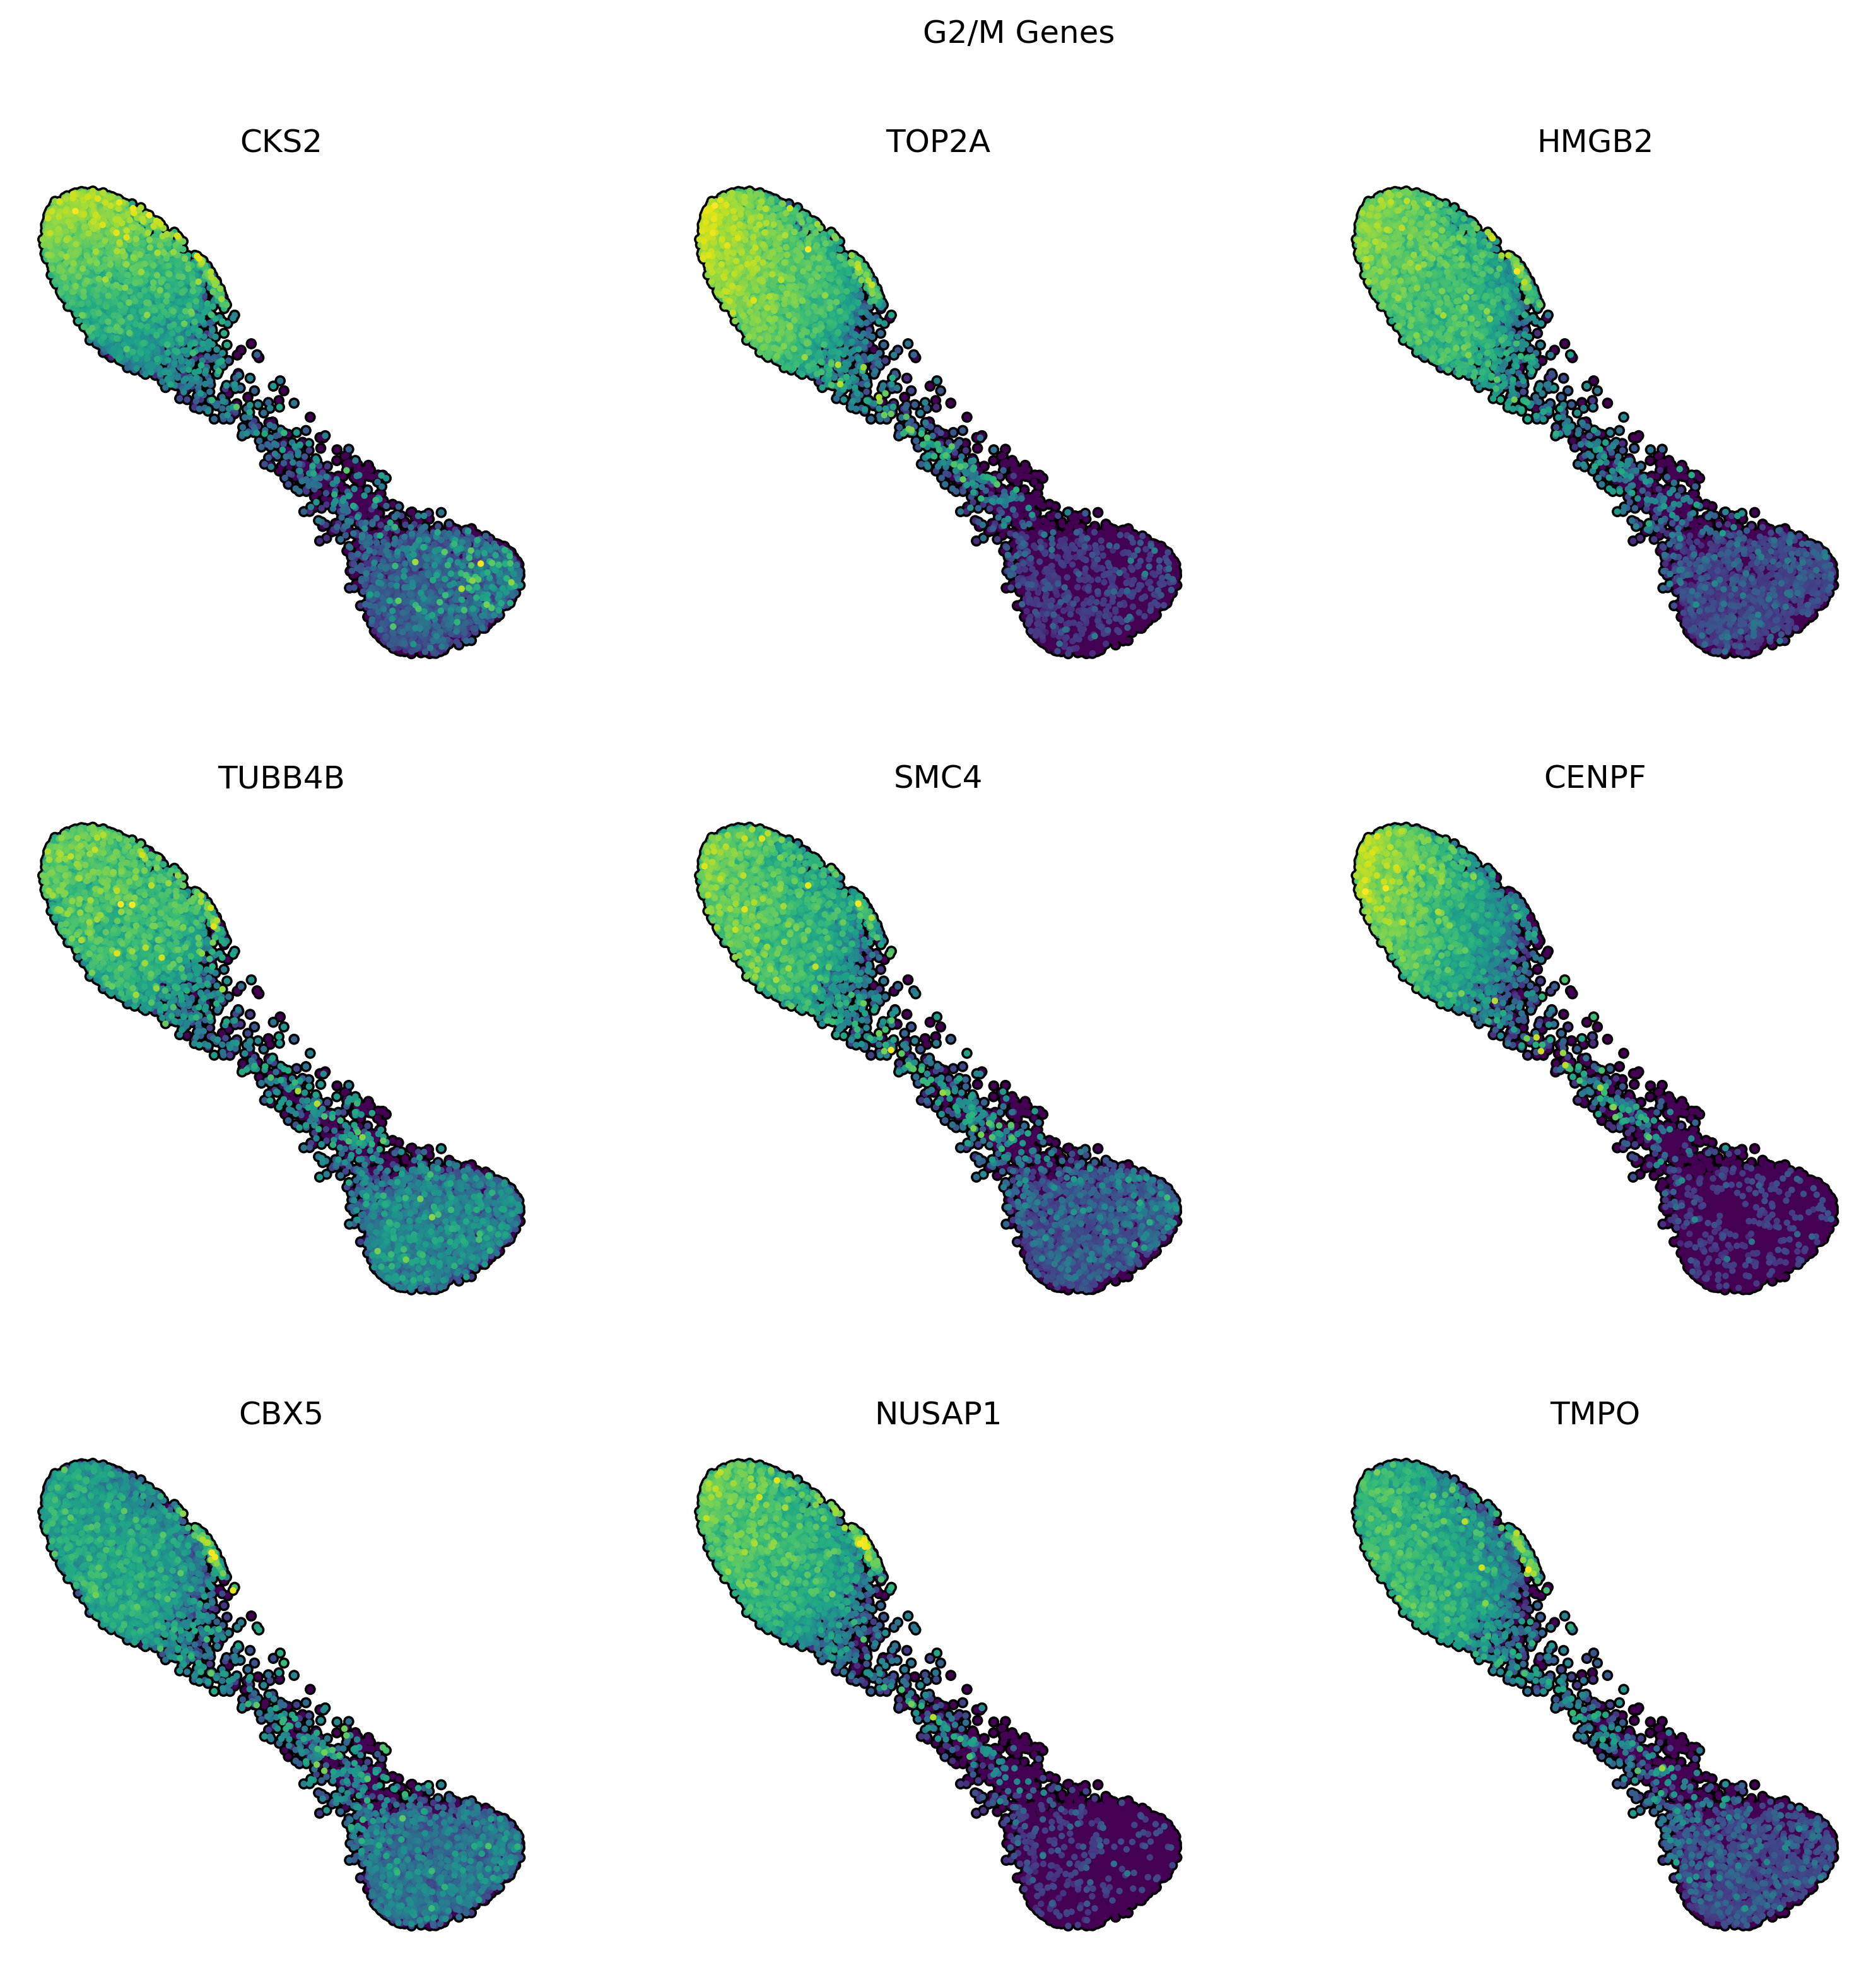

In [6]:
# get higest expressed S phase genes
g2m_genes = adata.uns['g2m_genes']
mean_expr = adata[:, g2m_genes].X.mean(axis=0).A1  
top9_genes = [g2m_genes[i] for i in mean_expr.argsort()[::-1][:9]]

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 3.25, 3.75

fig = sc.pl.draw_graph(
    adata, 
    color=top9_genes,
    size=25,
    ncols=3,
    alpha=1,
    use_raw=False,
    add_outline=True,
    na_in_legend=False,
    colorbar_loc=None,
    outline_color=('k', 'k'),
    frameon=False,
    show=False, 
    return_fig=True,  
)

fig.suptitle("G2/M Genes", y=0.95)
plt.show()

# pseudo time

In [7]:
adata

AnnData object with n_obs × n_vars = 7541 × 21412
    obs: 'phase', 'barcoded_phase', 'S_score', 'G2M_score'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'g2m_genes', 's_genes', 'pca', 'neighbors', 'paga', 'phase_sizes', 'phase_colors', 'draw_graph', 'barcoded_phase_colors'
    obsm: 'X_pca', 'X_draw_graph_fa'
    varm: 'PCs'
    layers: 'log_norm', 'raw_counts'
    obsp: 'distances', 'connectivities'

In [8]:
# Select the G1-phase cells, compute their median PCA vector,
# calculate the Euclidean distance from each G1 cell to this median,
# and return the cell closest to the median in PCA space.

# Get PCA coordinates for G1-phase cells
g1_mask = adata.obs['phase'] == 'G1'
g1_pca = adata.obsm['X_pca'][g1_mask]

# Compute median PCA vector
median_vec = np.median(g1_pca, axis=0)

# Compute Euclidean distance from each G1 cell to the median
dists = cdist(g1_pca, median_vec.reshape(1, -1)).flatten()

# Get the index of the closest G1 cell
closest_idx = np.argmin(dists)

# Retrieve the original adata index of the closest G1 cell
closest_cell_id = adata.obs_names[g1_mask][closest_idx]

closest_cell_id

'ACTCAATAGTGCTGTA-1'

[2025-05-08 16:51:40.471] [CUML] [debug] n_neighbors=5
[2025-05-08 16:51:40.471] [CUML] [debug] Calling knn graph run
[2025-05-08 16:51:40.471] [CUML] [debug] Done. Calling fuzzy simplicial set
[2025-05-08 16:51:40.472] [CUML] [debug] Done. Calling remove zeros
computing Diffusion Pseudotime using n_dcs=10
    finished: added
    'dpt_pseudotime', the pseudotime (adata.obs) (0:00:00)


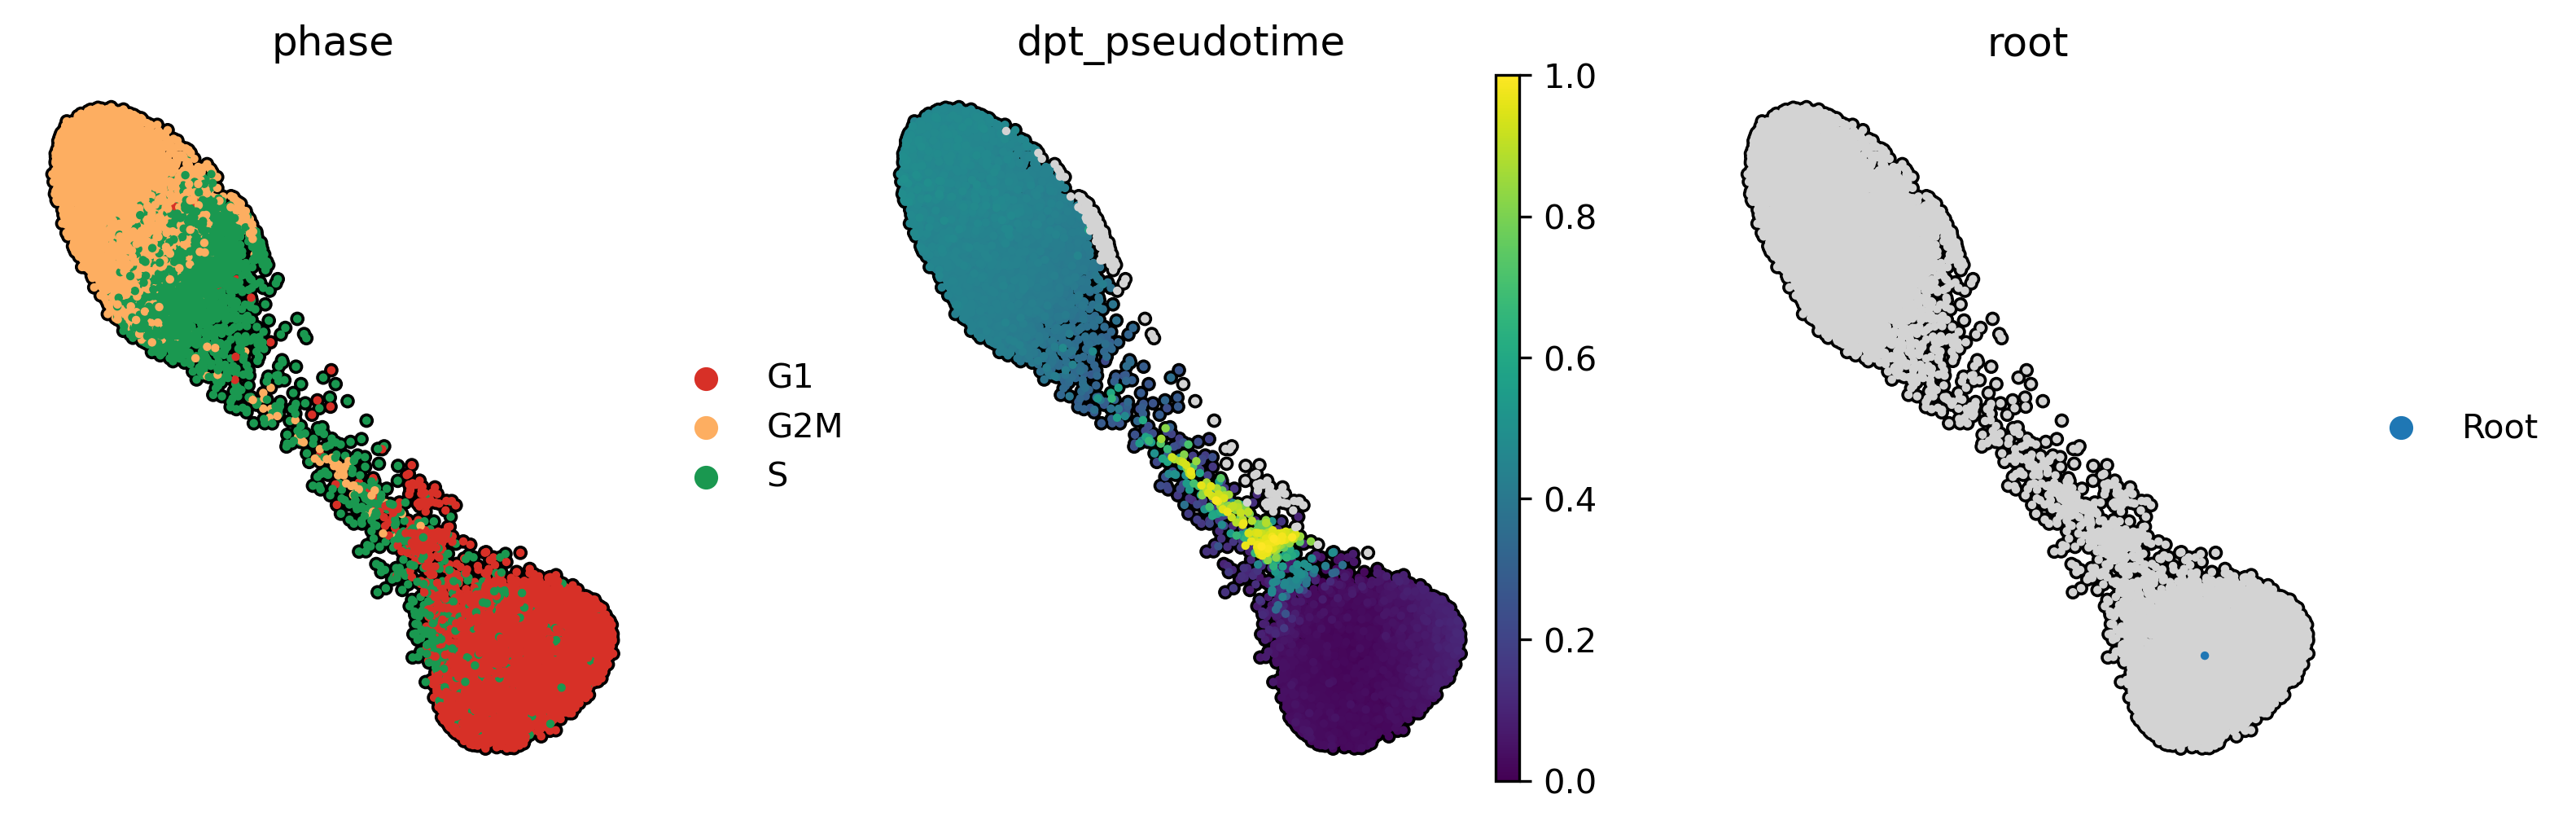

In [9]:
# rsc.pp.neighbors(adata, n_neighbors=100)
rsc.tl.diffmap(adata)
rsc.pp.neighbors(adata, n_neighbors=5, use_rep="X_diffmap")

# set root and compute pseudotime
adata.uns["iroot"] = list(adata.obs_names).index(closest_cell_id)
sc.tl.dpt(adata, allow_kendall_tau_shift=False)

# for plotting
adata.obs['root'] = np.where(adata.obs.index == closest_cell_id, 'Root', pd.NA)

sc.pl.draw_graph(
    adata, 
    color=['phase', 'dpt_pseudotime', 'root'],
    size=25,
    ncols=3,
    alpha=1,
    use_raw=False,
    add_outline=True,
    na_in_legend=False,
    outline_color=('k', 'k'),
    frameon=False,
)

In [10]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

In [ ]:
palette = {
    "G1": "#D73027",        # strong red (Cdt1+)
    "S": "#1A9850",         # green (Geminin+)
    "G2M": "#FDAE61",       # orange-yellow (Cdt1+/Geminin+)
    "unknown": "#B0B0B0", # Neutral gray
}

cc_data = adata[adata.obs['batch'] == 'fib', :].copy()
df = cc_data.obs.copy()

df['order'] = (df['g1_pseudotime'] - df['g1_pseudotime'].min()) / (df['g1_pseudotime'].max() - df['g1_pseudotime'].min())

# Define phase spans in hours
phase_lengths = {'G1': 12, 'S': 6, 'G2M': 6}
total_hours = 24
phase_angles = {}
start_angle = 0

# Compute angular positions for each phase (in radians)
for phase, hours in phase_lengths.items():
    phase_angles[phase] = (start_angle, start_angle + 2 * np.pi * hours / total_hours)
    start_angle = phase_angles[phase][1]

# Setup plot
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(6, 6))

# Draw donut sectors
for phase, (theta_start, theta_end) in phase_angles.items():
    width = theta_end - theta_start
    ax.bar(
        theta_start + width / 2,
        1.0,
        width=width,
        bottom=0,
        color=palette[phase],
        edgecolor='k',
        linewidth=1,
        alpha=0.2
    )
    ax.text(theta_start + width / 2, 1.05, phase, ha='center', va='center', fontsize=10)

for _, row in df.iterrows():
    angle = row['g1_pseudotime'] * 2 * np.pi  # Deterministic angle based on normalized pseudotime
    r = np.sqrt(np.random.normal(0.5, 0.1))  # Jitter in radius remains for visual separation
    ax.plot(angle, r, 'o', markersize=2, color='black', alpha=0.5)


ax.set_yticks([])
ax.set_xticks([])
ax.set_ylim(0, 1.1)
ax.spines['polar'].set_visible(False)
plt.tight_layout()
plt.show()

In [ ]:
break

# Psuedotime

In [ ]:
rsc.tl.diffmap(adata)
rsc.pp.neighbors(adata, n_neighbors=10, use_rep="X_diffmap")

# set root
adata.uns["iroot"] = np.flatnonzero(adata.obs["barcoded_phase"] == "G1")[0]

sc.tl.dpt(
    adata,
    n_branchings=3,
)

adata.obs['g1_pseudotime'] = adata.obs['dpt_pseudotime']
adata.obs['g1_order'] = adata.obs['dpt_order']

adata.uns["iroot"] = np.flatnonzero(adata.obs["barcoded_phase"] == "G2M")[0]

sc.tl.dpt(
    adata,
    n_branchings=1,
)

adata.obs['g2m_pseudotime'] = adata.obs['dpt_pseudotime']
adata.obs['g2m_order'] = adata.obs['dpt_order']

# include the mean of each
adata.obs['mean_pseudotime'] = adata.obs[['g1_pseudotime', 'g2m_pseudotime']].mean(axis=1)
adata.obs['mean_order'] = adata.obs[['g1_order', 'g2m_order']].mean(axis=1)

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4.25, 4.75

sc.pl.draw_graph(
    adata, 
    color=["cluster_str", 'barcoded_phase', 'g1_pseudotime', 'g2m_pseudotime'],
    size=25,
    ncols=2,
    alpha=1,
    use_raw=False,
    na_in_legend=False,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    wspace=0.75,
)

In [ ]:
%%time
cc_data = adata[adata.obs['batch'] == 'fib', :].copy()


# reprerform pseudotime on controls only
rsc.pp.neighbors(cc_data, n_neighbors=100, n_pcs=5, use_rep="X_diffmap")
cc_data.uns["iroot"] = np.flatnonzero(cc_data.obs["phase"] == "G1")[10]

sc.tl.dpt(cc_data)
sc.tl.draw_graph(cc_data)

palette = {
    "G1": "#D73027",        # strong red (Cdt1+)
    "S": "#1A9850",         # green (Geminin+)
    "G2M": "#FDAE61",       # orange-yellow (Cdt1+/Geminin+)
    "unknown": "#B0B0B0", # Neutral gray
}

sc.pl.draw_graph(
    cc_data,
    color=['dpt_pseudotime', 'phase'],
    size=25,
    ncols=2,
    alpha=1,
    use_raw=False,
    na_in_legend=False,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    palette=palette,
)


In [ ]:
break

In [ ]:
palette = {
    "G1": "#D73027",        # strong red (Cdt1+)
    "S": "#1A9850",         # green (Geminin+)
    "G2M": "#FDAE61",       # orange-yellow (Cdt1+/Geminin+)
    "unknown": "#B0B0B0", # Neutral gray
}

cc_data = adata[adata.obs['batch'] == 'fib', :].copy()
df = cc_data.obs.copy()

df['order'] = (df['g1_pseudotime'] - df['g1_pseudotime'].min()) / (df['g1_pseudotime'].max() - df['g1_pseudotime'].min())

# Define phase spans in hours
phase_lengths = {'G1': 12, 'S': 6, 'G2M': 6}
total_hours = 24
phase_angles = {}
start_angle = 0

# Compute angular positions for each phase (in radians)
for phase, hours in phase_lengths.items():
    phase_angles[phase] = (start_angle, start_angle + 2 * np.pi * hours / total_hours)
    start_angle = phase_angles[phase][1]

# Setup plot
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(6, 6))

# Draw donut sectors
for phase, (theta_start, theta_end) in phase_angles.items():
    width = theta_end - theta_start
    ax.bar(
        theta_start + width / 2,
        1.0,
        width=width,
        bottom=0,
        color=palette[phase],
        edgecolor='k',
        linewidth=1,
        alpha=0.2
    )
    ax.text(theta_start + width / 2, 1.05, phase, ha='center', va='center', fontsize=10)

for _, row in df.iterrows():
    angle = row['g1_pseudotime'] * 2 * np.pi  # Deterministic angle based on normalized pseudotime
    r = np.sqrt(np.random.normal(0.5, 0.1))  # Jitter in radius remains for visual separation
    ax.plot(angle, r, 'o', markersize=2, color='black', alpha=0.5)


ax.set_yticks([])
ax.set_xticks([])
ax.set_ylim(0, 1.1)
ax.spines['polar'].set_visible(False)
plt.tight_layout()
plt.show()

In [ ]:
break

In [ ]:
plt.figure(figsize=(4, 4))

ax = sns.scatterplot(
    data=adata.obs,
    x='g1_pseudotime',
    y='g2m_pseudotime',
    hue='cluster_str',
    s=10,           
    edgecolor='black',
    linewidth=0.3,
    legend=False,
)

ax.set_xlabel("G1 Pseudotime")
ax.set_ylabel("G2/M Pseudotime")

lims = [
    min(ax.get_xlim()[0], ax.get_ylim()[0]),
    max(ax.get_xlim()[1], ax.get_ylim()[1]),
]
ax.plot(lims, lims, '--', color='k', linewidth=1)
ax.set_xlim(lims)
ax.set_ylim(lims)

sns.despine()
plt.tight_layout()

# Compare "average" DPT with DPT from "average"

- "average" DPT is the mean of DPT from different root cells
- DPT from "average" is the DPT from root cells that are the mean

In [ ]:
adata = adata[~adata.obs['barcoded_phase'].isna()].copy()

aggdata = sc.get.aggregate(
    adata,
    by='barcoded_phase',
    func='mean',
    axis=0,
)

aggdata.X = aggdata.layers['mean']
aggdata.obs['g2m_pseudotime'] = pd.NA
aggdata.obs['g1_pseudotime'] = pd.NA
aggdata.obs['mean_pseudotime'] = pd.NA

# add harmony
aggdata.obsm['X_pca_harmony'] = sc.get.aggregate(
    adata,
    by='barcoded_phase',
    func='mean',
    axis=0,
    obsm='X_pca_harmony',
).layers['mean'].copy()

# drop unknown
aggdata = aggdata[aggdata.obs['barcoded_phase'] != 'unknown', :].copy()

# combine
merge = an.concat(
    [adata, aggdata], 
    axis=0, 
    join='inner', 
    merge='same',
    fill_value=0,
    label='aggregate',
)


# set up DPT
rsc.pp.neighbors(merge, n_neighbors=200, n_pcs=25, use_rep='X_pca_harmony')
rsc.tl.diffmap(merge)
rsc.pp.neighbors(merge, n_neighbors=10, use_rep="X_diffmap")

# iterate through each average init point
for agg_point in merge.obs_names[-3:]:

    # set root
    idx = list(merge.obs_names).index(agg_point)
    merge.uns["iroot"] = idx
    
    sc.tl.dpt(merge, n_branchings=3)
    merge.obs[f'{agg_point}_pseudotime'] = merge.obs['dpt_pseudotime']

merge

In [ ]:
X = merge.obs[['g1_pseudotime', 'g2m_pseudotime', 'mean_pseudotime', 'G1_pseudotime', 'G2M_pseudotime', 'S_pseudotime']].corr()

sns.heatmap(
    data=X,
    square=True,
    cbar_kws={'shrink' : 0.4},
    annot=True,
    fmt=".2f",
    cmap="bwr",
    lw=1,
    linecolor='k',
)


In [ ]:
sns.pairplot(
    merge.obs[['g1_pseudotime', 
               'g2m_pseudotime', 
               'mean_pseudotime',
               'G1_pseudotime',
               'G2M_pseudotime',
               'S_pseudotime']], 
)

# Nice Figures

In [ ]:
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.draw_graph(
    adata, 
    color=['cluster_str'],
    size=25,
    ncols=3,
    alpha=1,
    use_raw=False,
    add_outline=True,
    outline_color=('k', 'k'),
    title="",
    frameon=False,
    wspace=0.5,
)

In [ ]:
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 4, 4

palette = {
    "G1": "#D73027",        # strong red (Cdt1+)
    "S": "#1A9850",         # green (Geminin+)
    "G2M": "#FDAE61",       # orange-yellow (Cdt1+/Geminin+)
    "unknown": "#B0B0B0", # Neutral gray
}

sc.pl.draw_graph(
    adata, 
    color=['barcoded_phase'],
    sort_order=True,
    size=15,
    ncols=3,
    alpha=1,
    use_raw=False,
    add_outline=True,
    outline_color=('k', 'k'),
    na_in_legend=False,
    title="",
    frameon=False,
    wspace=0.5,
    palette=palette,
)

In [ ]:
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.draw_graph(
    adata, 
    color=['phase'],
    sort_order=True,
    size=15,
    ncols=3,
    alpha=1,
    use_raw=False,
    add_outline=True,
    outline_color=('k', 'k'),
    na_in_legend=False,
    title="",
    frameon=False,
    wspace=0.5,
    palette=palette,
)

In [ ]:
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 4.25, 4.75

sc.pl.draw_graph(
    adata, 
    color=['mean_pseudotime', 'CD34'],
    size=25,
    ncols=3,
    alpha=1,
    use_raw=False,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    wspace=0.5,
)

In [ ]:
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.draw_graph(
    adata, 
    color=['mean_pseudotime'],
    sort_order=True,
    size=15,
    ncols=3,
    alpha=1,
    use_raw=False,
    add_outline=True,
    outline_color=('k', 'k'),
    na_in_legend=False,
    colorbar_loc=None,
    title="",
    frameon=False,
    wspace=0.5,
    cmap='inferno'
)